# Baseline Models (TF-IDF)

Melatih model klasik (SVM, Logistic Regression, Naive Bayes) sebagai baseline evaluasi.

In [1]:
import pandas as pd
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, precision_score, recall_score
)

# Styling global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv').fillna('')
test_df = pd.read_csv('../data/test.csv').fillna('')

X_train, y_train = train_df['text'], train_df['label']
X_test, y_test = test_df['text'], test_df['label']

le = joblib.load('../models/label_encoder.pkl')
target_names = le.classes_

## 2. Inisialisasi Model

In [3]:
models = {
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
        ('clf', LinearSVC())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', MultinomialNB())
    ])
}

## 3. Training & Evaluasi

In [4]:
results = []
all_predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)
    all_predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1,
                    'Precision': prec, 'Recall': rec})
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    print("-"*50)
    
    # Simpan model
    joblib.dump(model, f'../models/{name.replace(" ", "_").lower()}_model.pkl')

Training SVM...
Evaluating SVM...

SVM Results:
                         precision    recall  f1-score   support

                   APBN       0.70      0.60      0.65        55
             Agribisnis       0.88      0.70      0.78        66
                Ekonomi       0.85      0.84      0.84       775
         Ekonomi Global       0.91      0.94      0.93       331
       Energi & Tambang       0.94      0.96      0.95       557
          Infrastruktur       0.93      0.89      0.91       222
           Jasa & Niaga       0.88      0.88      0.88       693
             Manufaktur       0.84      0.84      0.84       312
                  Pajak       0.82      0.79      0.81       107
               Properti       0.92      0.92      0.92       306
Transportasi & Logistik       0.96      0.98      0.97      1010

               accuracy                           0.90      4434
              macro avg       0.88      0.85      0.86      4434
           weighted avg       0.90      

## 4. Visualisasi — Confusion Matrix

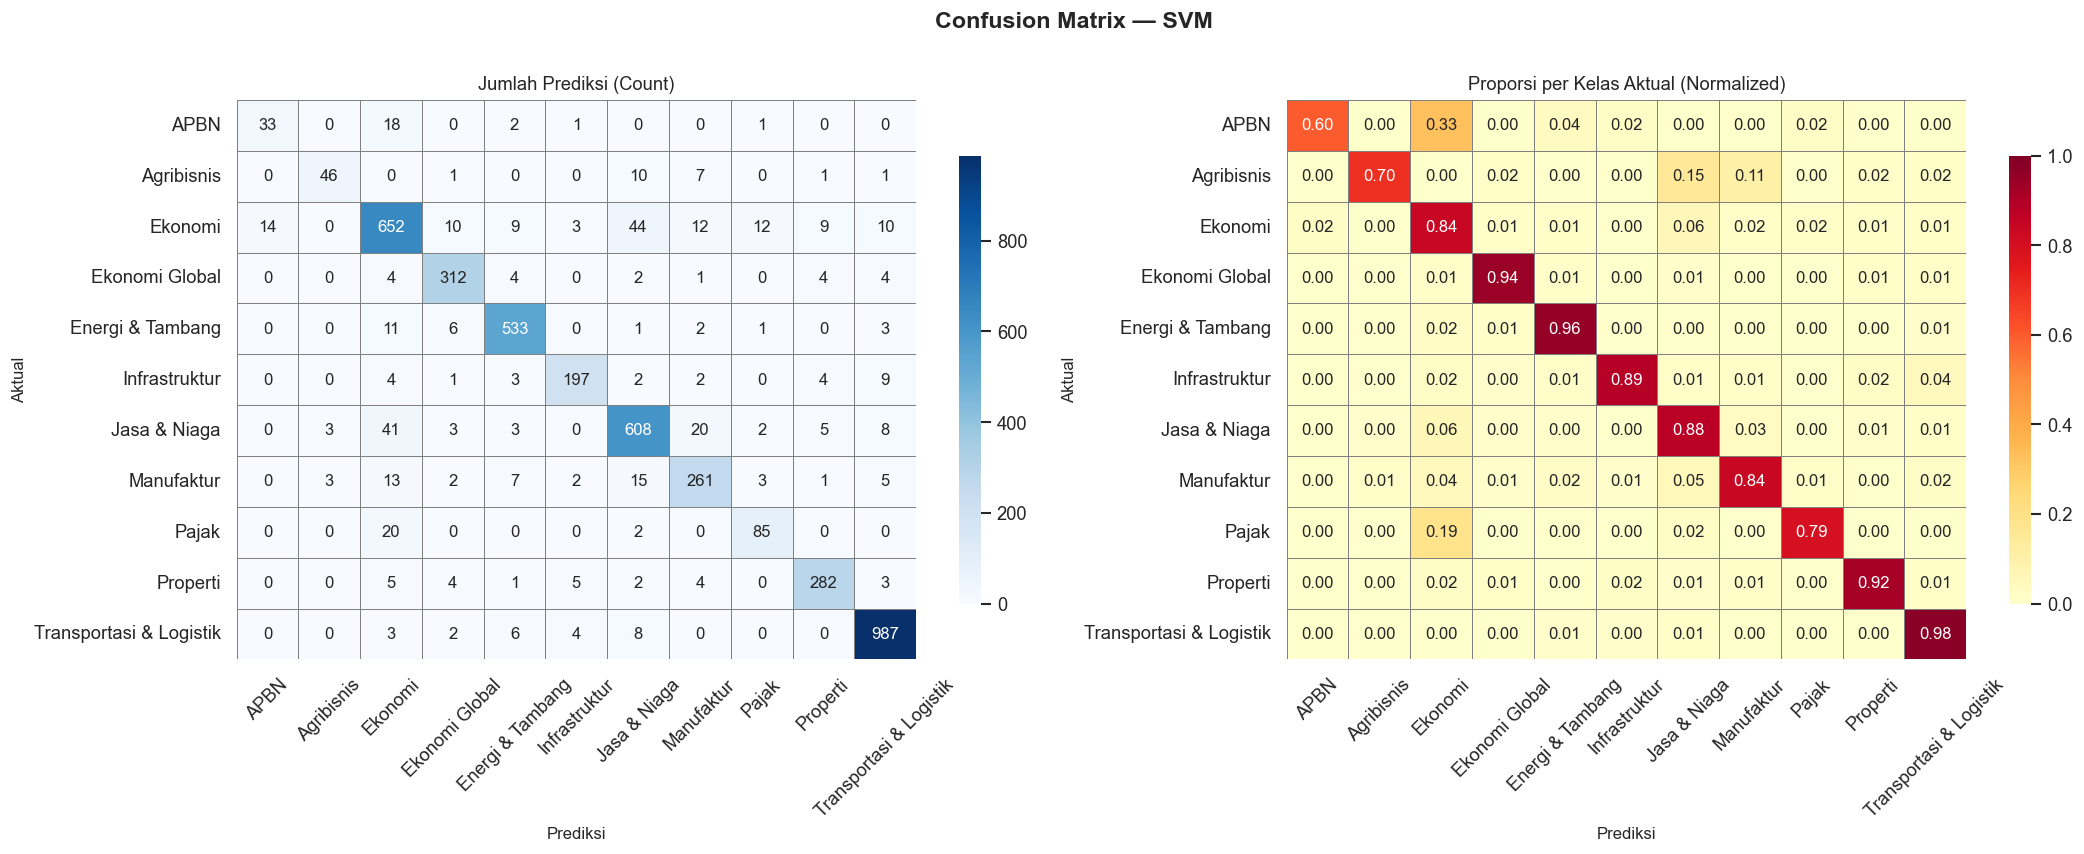

  ✓ Gambar disimpan: ../outputs/figures/cm_svm.png



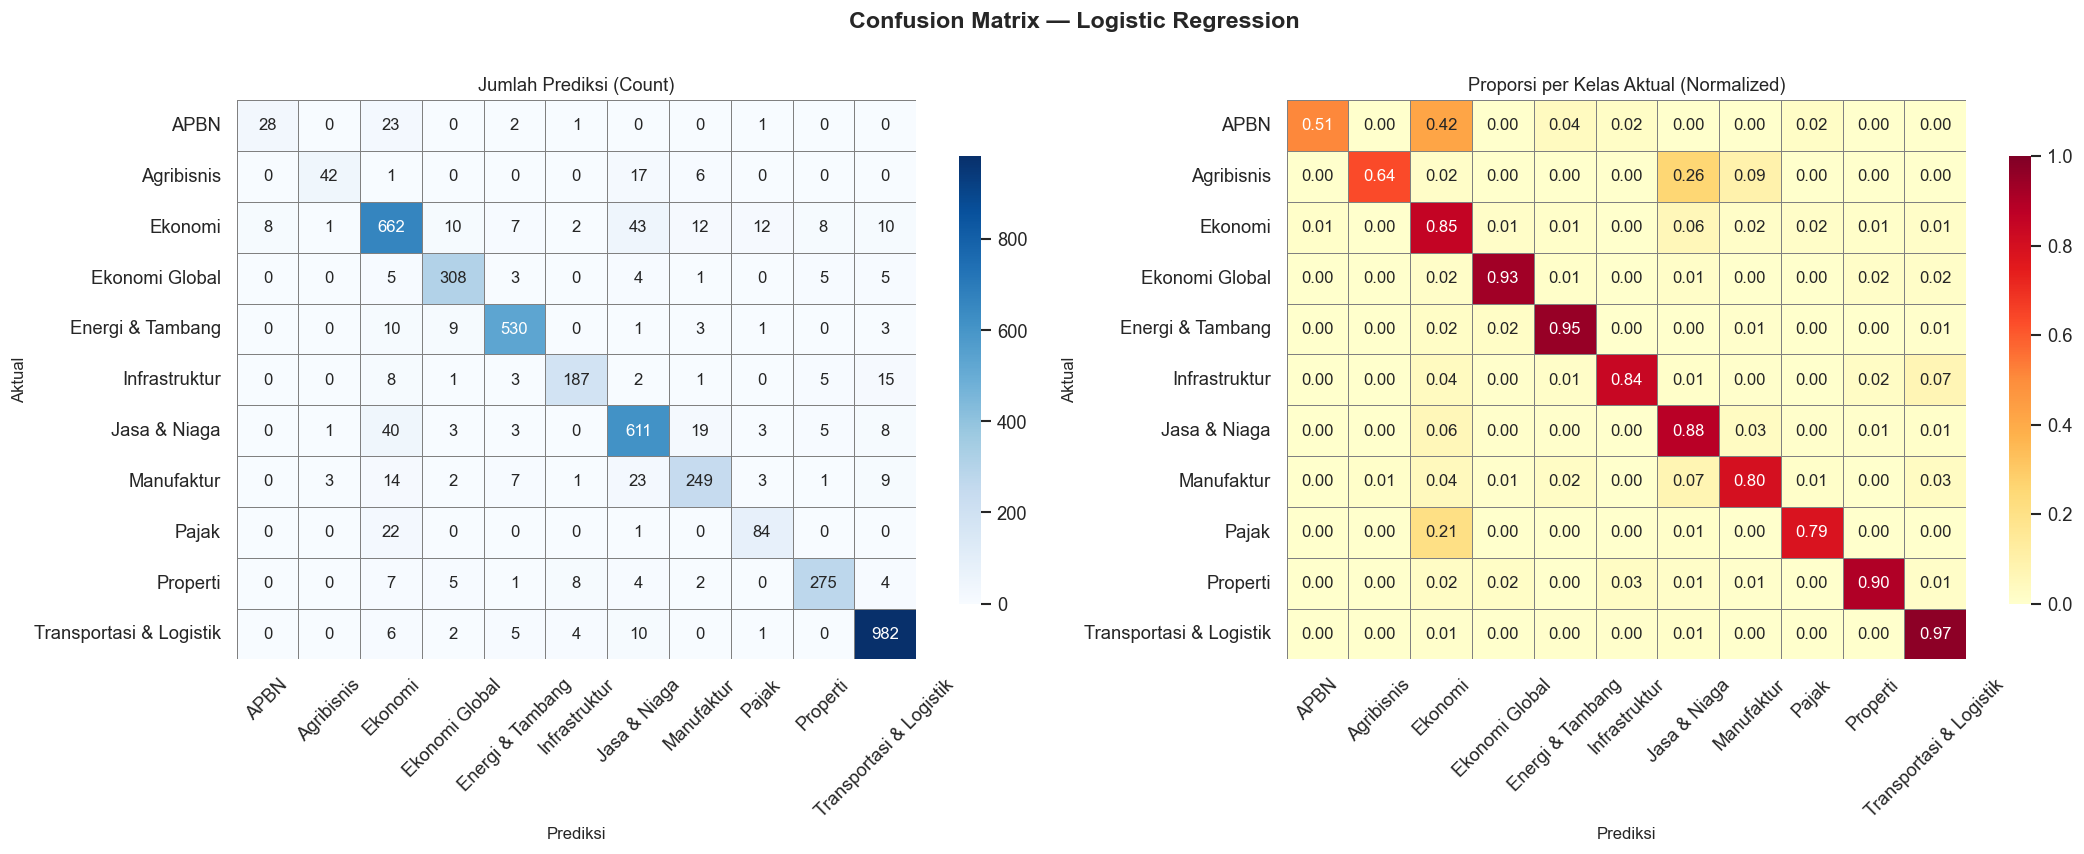

  ✓ Gambar disimpan: ../outputs/figures/cm_logistic_regression.png



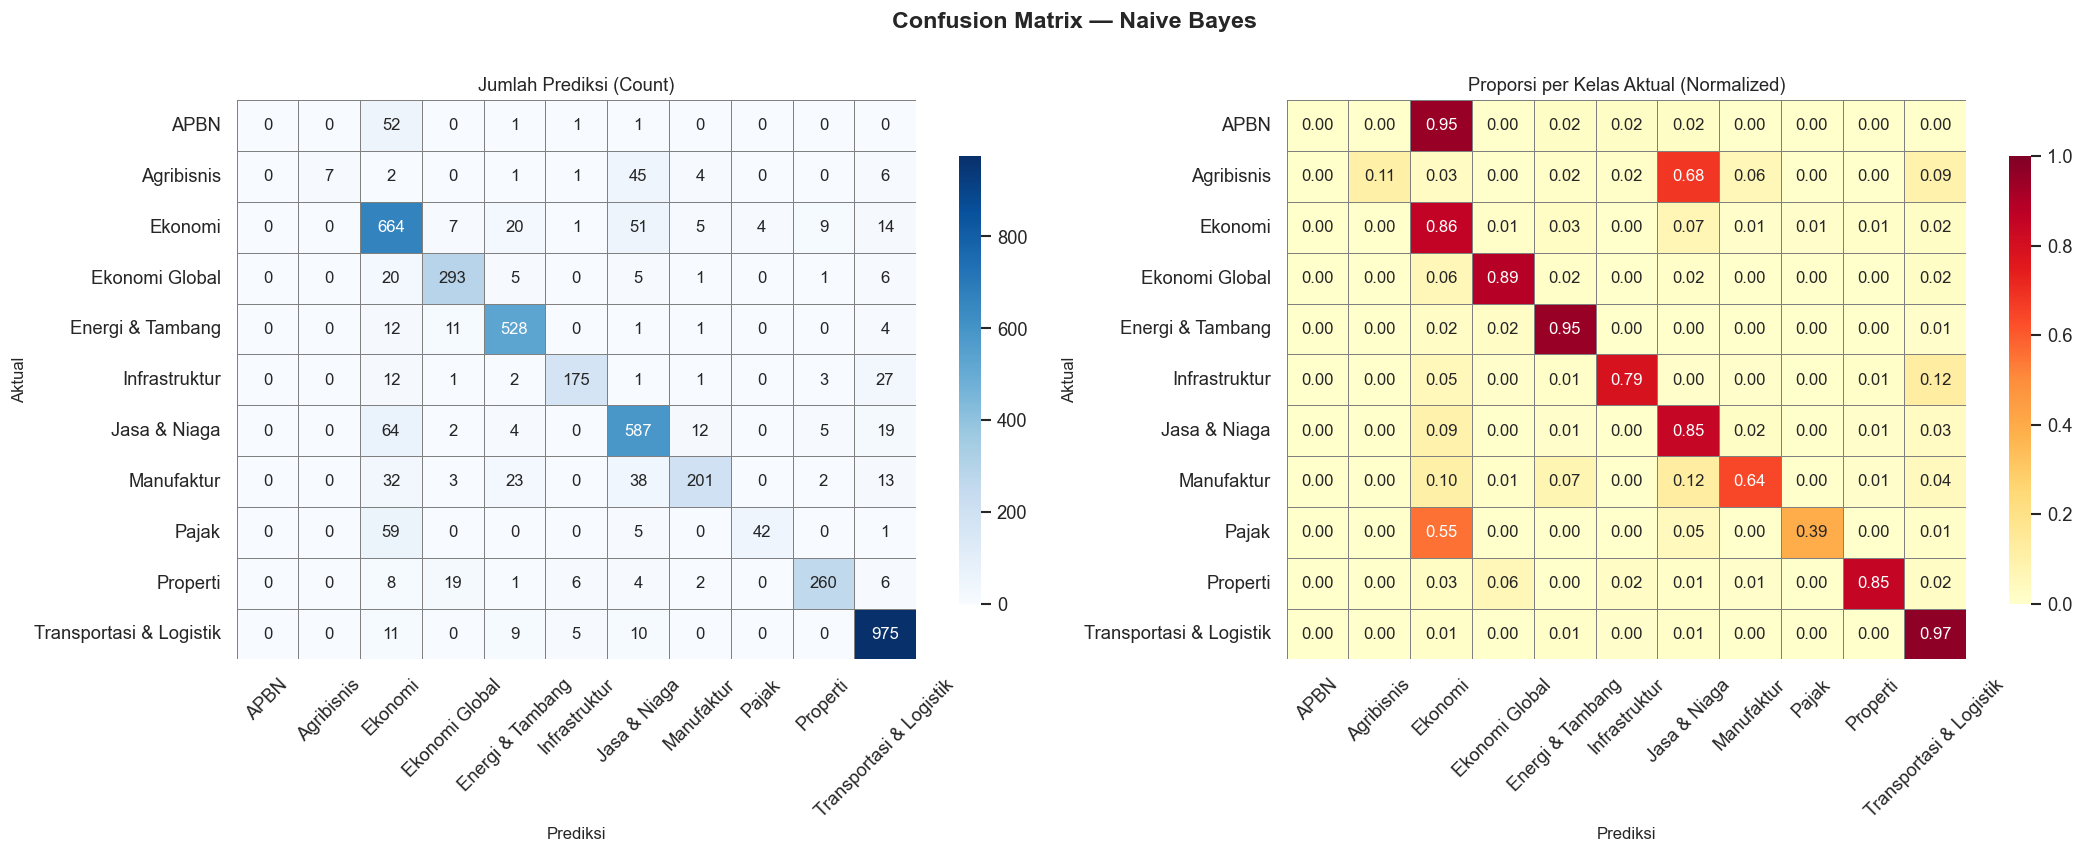

  ✓ Gambar disimpan: ../outputs/figures/cm_naive_bayes.png



In [5]:
def plot_confusion_matrix(y_true, y_pred, model_name, target_names):
    """Plot heatmap confusion matrix yang rapi."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalisasi per baris

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold', y=1.01)

    # --- Raw counts ---
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=target_names, yticklabels=target_names,
        linewidths=0.5, linecolor='grey',
        ax=axes[0], cbar_kws={'shrink': 0.8}
    )
    axes[0].set_title('Jumlah Prediksi (Count)', fontsize=11)
    axes[0].set_xlabel('Prediksi', fontsize=10)
    axes[0].set_ylabel('Aktual', fontsize=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # --- Normalized ---
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
        xticklabels=target_names, yticklabels=target_names,
        linewidths=0.5, linecolor='grey', vmin=0, vmax=1,
        ax=axes[1], cbar_kws={'shrink': 0.8}
    )
    axes[1].set_title('Proporsi per Kelas Aktual (Normalized)', fontsize=11)
    axes[1].set_xlabel('Prediksi', fontsize=10)
    axes[1].set_ylabel('Aktual', fontsize=10)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    os.makedirs('../outputs/figures', exist_ok=True)
    fname = f'../outputs/figures/cm_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Gambar disimpan: {fname}\n')

for name, y_pred in all_predictions.items():
    plot_confusion_matrix(y_test, y_pred, name, target_names)

## 5. Visualisasi — Metrik per Kelas (F1-Score)

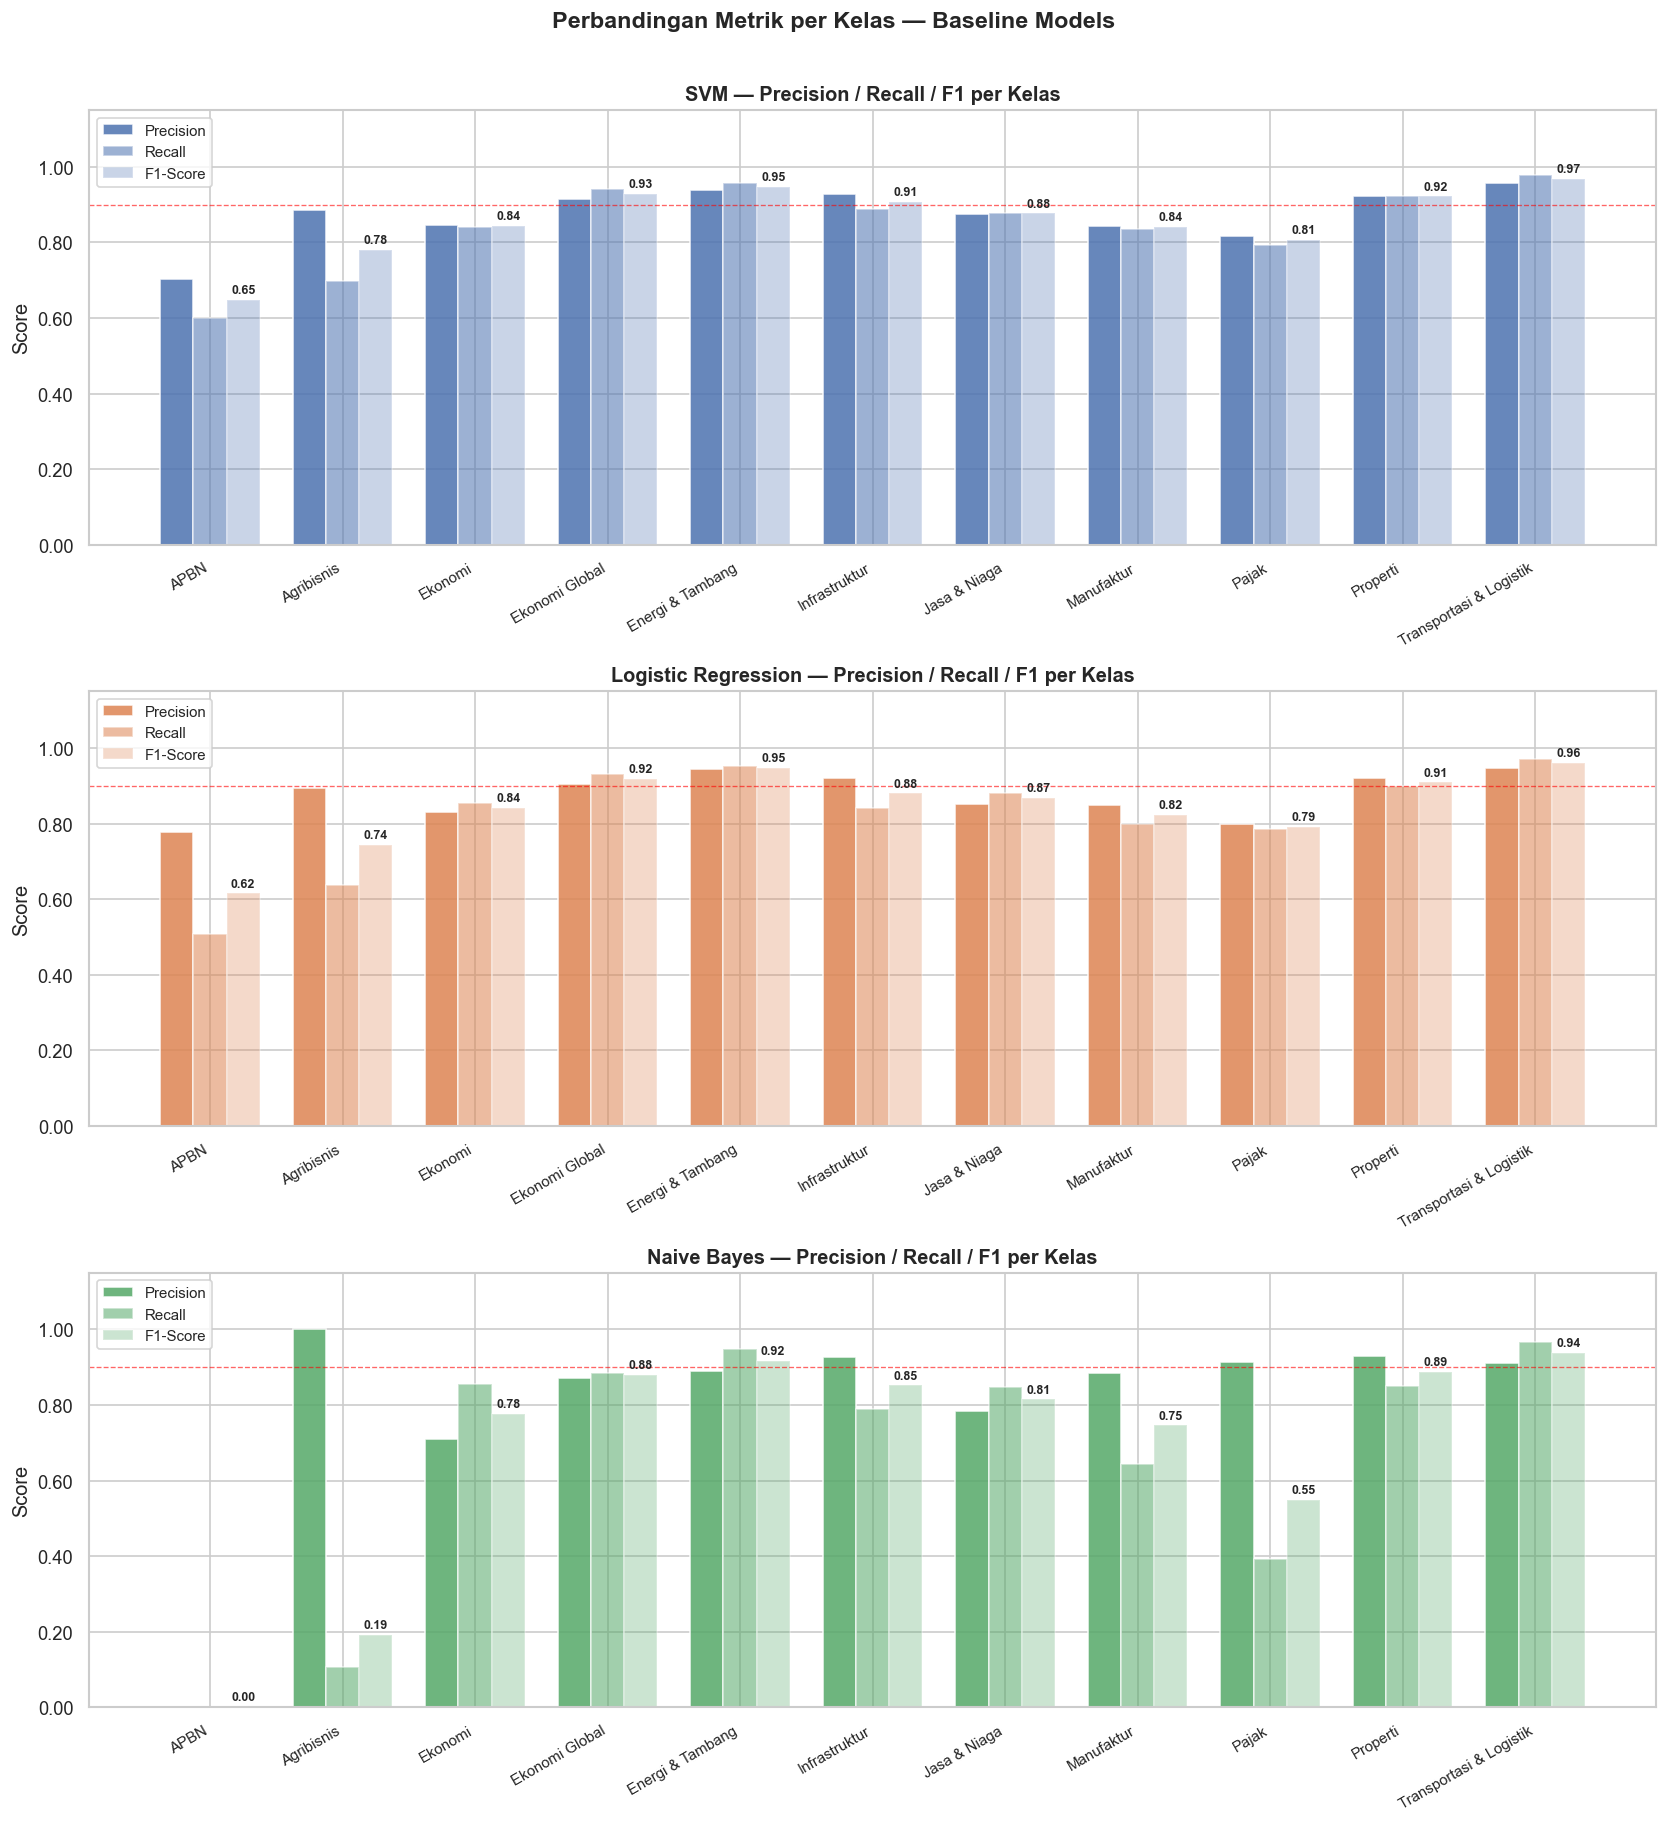

✓ Gambar disimpan: ../outputs/figures/baseline_per_class_metrics.png


In [6]:
from sklearn.metrics import precision_recall_fscore_support

fig, axes = plt.subplots(len(all_predictions), 1,
                          figsize=(14, 5 * len(all_predictions)),
                          sharex=False)
if len(all_predictions) == 1:
    axes = [axes]

colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (name, y_pred), color in zip(axes, all_predictions.items(), colors):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=np.arange(len(target_names)),
        zero_division=0
    )

    x = np.arange(len(target_names))
    width = 0.25

    bars_p = ax.bar(x - width, prec, width, label='Precision', color=color, alpha=0.85)
    bars_r = ax.bar(x,         rec,  width, label='Recall',    color=color, alpha=0.55)
    bars_f = ax.bar(x + width, f1,   width, label='F1-Score',  color=color, alpha=0.30)

    # Anotasi nilai F1
    for bar, val in zip(bars_f, f1):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_title(f'{name} — Precision / Recall / F1 per Kelas', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(target_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Threshold 0.90')

plt.suptitle('Perbandingan Metrik per Kelas — Baseline Models', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/baseline_per_class_metrics.png', bbox_inches='tight')
plt.show()
print('✓ Gambar disimpan: ../outputs/figures/baseline_per_class_metrics.png')

## 6. Visualisasi 

Perbandingan Keseluruhan Model

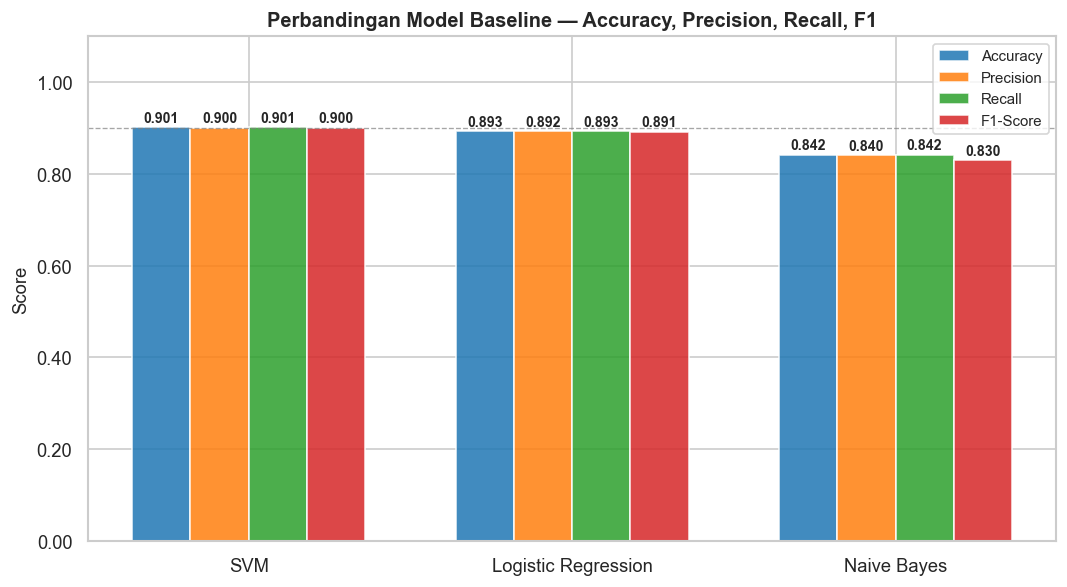

✓ Gambar disimpan: ../outputs/figures/baseline_overall_comparison.png


In [7]:
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.18
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (metric, col) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=col, alpha=0.85)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Perbandingan Model Baseline — Accuracy, Precision, Recall, F1',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.savefig('../outputs/figures/baseline_overall_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Gambar disimpan: ../outputs/figures/baseline_overall_comparison.png')

## 7. Simpan Hasil Baseline

In [8]:
os.makedirs('../outputs', exist_ok=True)
results_df.to_csv('../outputs/baseline_results.csv', index=False)
print("Hasil baseline disimpan ke '../outputs/baseline_results.csv'")
print(results_df.to_string(index=False))

Hasil baseline disimpan ke '../outputs/baseline_results.csv'
              Model  Accuracy  F1-Score  Precision   Recall
                SVM  0.901218  0.900490   0.900350 0.901218
Logistic Regression  0.892648  0.891498   0.892233 0.892648
        Naive Bayes  0.841678  0.829737   0.840438 0.841678
